In [13]:
# !pip install mlflow scikit-learn pandas matplotlib --quiet

import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
SUBSAMPLE = 20000   # lower to 10000 if runs are slow — record whichever you use
EPOCHS = 25

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mnist-mlp")
print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://localhost:5000


In [14]:
CACHE = "mnist_cache.npz"

if os.path.exists(CACHE):
    print(f"Loading MNIST from cache: {CACHE}")
    data = np.load(CACHE)
    X_full, y_full = data["X"], data["y"]
else:
    print("Downloading MNIST from OpenML (first run only)...")
    mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
    X_full = mnist.data.astype(np.uint8)
    y_full = mnist.target.astype(np.int64)
    np.savez_compressed(CACHE, X=X_full, y=y_full)
    print(f"Cached to {CACHE}")

print("X:", X_full.shape, X_full.dtype)
print("y:", y_full.shape, "| classes:", sorted(set(y_full.tolist())))

Loading MNIST from cache: mnist_cache.npz
X: (70000, 784) uint8
y: (70000,) | classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [15]:
X = X_full.astype(np.float32) / 255.0
y = y_full

if SUBSAMPLE and SUBSAMPLE < len(X):
    rng = np.random.RandomState(SEED)
    idx = rng.choice(len(X), size=SUBSAMPLE, replace=False)
    X, y = X[idx], y[idx]
    print(f"Subsampled to {SUBSAMPLE} images.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print("train:", X_train.shape, "| validation:", X_test.shape)

Subsampled to 20000 images.
train: (16000, 784) | validation: (4000, 784)


In [16]:
def train_and_evaluate(learning_rate_init=0.001, batch_size=128,
                       hidden_layer_sizes=(128,), alpha=1e-4, epochs=5):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        alpha=alpha,
        solver="adam",
        activation="relu",
        random_state=SEED,
        max_iter=epochs,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro")
    return model, acc, f1


# Sanity check — no MLflow involved yet
t0 = time.time()
_, acc, f1 = train_and_evaluate()
print(f"accuracy={acc:.4f}  f1_macro={f1:.4f}  ({time.time() - t0:.1f}s)")
def train_and_log(learning_rate_init, batch_size,
                  hidden_layer_sizes=(128,), alpha=1e-4,
                  epochs=EPOCHS, run_name=None):
    """Train one MLP and log parameters, metrics and artifacts to MLflow."""

    run_name = run_name or f"mlp-lr{learning_rate_init}-bs{batch_size}"

    with mlflow.start_run(run_name=run_name) as run:

        # --- parameters (at least 3) ---
        mlflow.log_params({
            "model_type": "MLPClassifier",
            "dataset": "MNIST",
            "hidden_layer_sizes": str(hidden_layer_sizes),
            "learning_rate_init": learning_rate_init,
            "batch_size": batch_size,
            "alpha": alpha,
            "epochs": epochs,
            "solver": "adam",
            "activation": "relu",
            "subsample": SUBSAMPLE,
            "seed": SEED,
        })

        mlflow.set_tag("team", "data-science")
        mlflow.set_tag("assignment", "module1-q2")

        model = MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            learning_rate_init=learning_rate_init,
            batch_size=batch_size,
            alpha=alpha,
            solver="adam",
            activation="relu",
            random_state=SEED,
            max_iter=1,        # one epoch per fit() call...
            warm_start=True,   # ...continuing from the previous weights
        )

        t0 = time.time()
        best_acc, best_epoch = 0.0, -1

        # --- metrics (at least 2), logged once per epoch as a time series ---
        for epoch in range(epochs):
            model.fit(X_train, y_train)

            train_loss = model.loss_
            val_proba = model.predict_proba(X_test)
            val_acc = accuracy_score(y_test, np.argmax(val_proba, axis=1))
            val_loss = log_loss(y_test, val_proba, labels=np.arange(10))
            train_acc = accuracy_score(y_train, model.predict(X_train))

            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_accuracy", val_acc, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("train_accuracy", train_acc, step=epoch)
            mlflow.log_metric("generalization_gap", train_acc - val_acc, step=epoch)

            if val_acc > best_acc:
                best_acc, best_epoch = val_acc, epoch

        elapsed = time.time() - t0

        # --- final summary metrics (what the comparison table sorts on) ---
        preds = model.predict(X_test)
        mlflow.log_metrics({
            "final_val_accuracy": accuracy_score(y_test, preds),
            "final_f1_macro": f1_score(y_test, preds, average="macro"),
            "final_train_loss": model.loss_,
            "best_val_accuracy": best_acc,
            "best_epoch": best_epoch,
            "train_time_sec": elapsed,
        })

        # --- artifacts ---
        pd.DataFrame({
            "epoch": range(len(model.loss_curve_)),
            "train_loss": model.loss_curve_,
        }).to_csv("loss_curve.csv", index=False)
        mlflow.log_artifact("loss_curve.csv")
        os.remove("loss_curve.csv")

        signature = infer_signature(X_test[:5], model.predict(X_test[:5]))
        mlflow.sklearn.log_model(
            model,
            name="model",
            signature=signature,
            input_example=X_test[:5],
            serialization_format="cloudpickle",
        )

        run_id = run.info.run_id
        print(f"{run_name:26s} best_val_acc={best_acc:.4f} @epoch {best_epoch:<3d} "
              f"final_loss={model.loss_:.4f}  ({elapsed:.0f}s)")
        return run_id

accuracy=0.9440  f1_macro=0.9435  (1.7s)


In [17]:
LEARNING_RATES = [0.0001, 0.001, 0.01]
BATCH_SIZES = [32, 256]

sweep_run_ids = []
for lr in LEARNING_RATES:
    for bs in BATCH_SIZES:
        sweep_run_ids.append(train_and_log(learning_rate_init=lr, batch_size=bs))

print(f"\nSweep complete — {len(sweep_run_ids)} runs.")
print("Sweep run IDs:", sweep_run_ids)

2026/08/30 03:42:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


mlp-lr0.0001-bs32          best_val_acc=0.9495 @epoch 24  final_loss=0.1147  (15s)
🏃 View run mlp-lr0.0001-bs32 at: http://localhost:5000/#/experiments/1/runs/533eb09c51274c9cbe612514ed300ac1
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/08/30 03:42:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


mlp-lr0.0001-bs256         best_val_acc=0.9263 @epoch 24  final_loss=0.2310  (7s)
🏃 View run mlp-lr0.0001-bs256 at: http://localhost:5000/#/experiments/1/runs/acf7007041834b21a01295ab43d5fac1
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/08/30 03:42:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

mlp-lr0.001-bs256          best_val_acc=0.9615 @epoch 24  final_loss=0.0233  (7s)
🏃 View run mlp-lr0.001-bs256 at: http://localhost:5000/#/experiments/1/runs/ec6ddab6e4814928bb507adc51b7d280
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/08/30 03:43:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


mlp-lr0.01-bs32            best_val_acc=0.9523 @epoch 8   final_loss=0.1136  (12s)
🏃 View run mlp-lr0.01-bs32 at: http://localhost:5000/#/experiments/1/runs/ed856779134541018d86899d734d9a29
🧪 View experiment at: http://localhost:5000/#/experiments/1


2026/08/30 03:43:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


mlp-lr0.01-bs256           best_val_acc=0.9625 @epoch 19  final_loss=0.0304  (7s)
🏃 View run mlp-lr0.01-bs256 at: http://localhost:5000/#/experiments/1/runs/ca2550fb23fb47e29459c8be70aa4b75
🧪 View experiment at: http://localhost:5000/#/experiments/1

Sweep complete — 6 runs.
Sweep run IDs: ['533eb09c51274c9cbe612514ed300ac1', 'acf7007041834b21a01295ab43d5fac1', '9f7a5a37776d493e8711b722854a3803', 'ec6ddab6e4814928bb507adc51b7d280', 'ed856779134541018d86899d734d9a29', 'ca2550fb23fb47e29459c8be70aa4b75']


In [18]:
# =====================================================================
# CLEANUP — remove smoke-test runs and older duplicate sweeps
#
# The sweep was executed more than once, so the experiment holds several
# runs per configuration. Old copies are deleted so that both the plots
# below and the MLflow UI comparison show exactly six runs.
#
# Set DRY_RUN = False to actually delete.
# =====================================================================
DRY_RUN = True

import mlflow
import pandas as pd

client = mlflow.tracking.MlflowClient()

all_runs = mlflow.search_runs(
    experiment_names=["mnist-mlp"],
    order_by=["start_time DESC"],
)
print(f"Runs currently in the experiment: {len(all_runs)}")

names = all_runs["tags.mlflow.runName"].astype(str)

# 1. every smoke-test run, whatever its capitalisation
is_smoke = names.str.upper().str.contains("SMOKE")

# 2. duplicates: keep only the most recent run of each name
is_dupe = names.duplicated(keep="first") & ~is_smoke

to_delete = all_runs[is_smoke | is_dupe]
to_keep = all_runs[~(is_smoke | is_dupe)]

print(f"  smoke-test runs : {is_smoke.sum()}")
print(f"  older duplicates: {is_dupe.sum()}")
print(f"  will delete     : {len(to_delete)}")
print(f"  will keep       : {len(to_keep)}")

print("\nKeeping:")
for _, r in to_keep.iterrows():
    print(f"  {r['tags.mlflow.runName']:24s} {r['run_id']}")

if DRY_RUN:
    print("\nDRY_RUN = True — nothing deleted. Set DRY_RUN = False and re-run.")
else:
    for rid in to_delete["run_id"]:
        client.delete_run(rid)
    print(f"\nDeleted {len(to_delete)} runs.")

Runs currently in the experiment: 37
  smoke-test runs : 1
  older duplicates: 30
  will delete     : 31
  will keep       : 6

Keeping:
  mlp-lr0.01-bs256         ca2550fb23fb47e29459c8be70aa4b75
  mlp-lr0.01-bs32          ed856779134541018d86899d734d9a29
  mlp-lr0.001-bs256        ec6ddab6e4814928bb507adc51b7d280
  mlp-lr0.001-bs32         9f7a5a37776d493e8711b722854a3803
  mlp-lr0.0001-bs256       acf7007041834b21a01295ab43d5fac1
  mlp-lr0.0001-bs32        533eb09c51274c9cbe612514ed300ac1

DRY_RUN = True — nothing deleted. Set DRY_RUN = False and re-run.


In [19]:
# =====================================================================
# Comparison table — exactly six runs
#
# Two fixes over the previous version:
#   1. the smoke-test filter is now case-insensitive (the run was named
#      "SMOKE-TEST-delete-me", so startswith("smoke-test") never matched)
#   2. duplicate sweeps are collapsed to the most recent run per config
# =====================================================================
runs_df = mlflow.search_runs(
    experiment_names=["mnist-mlp"],
    order_by=["start_time DESC"],          # newest first, so keep="first" wins
)
print(f"Runs returned by search_runs: {len(runs_df)}")

names = runs_df["tags.mlflow.runName"].astype(str)
runs_df = runs_df[~names.str.upper().str.contains("SMOKE")]
print(f"After removing smoke tests : {len(runs_df)}")

runs_df = runs_df[~runs_df["tags.mlflow.runName"].astype(str).duplicated(keep="first")]
print(f"After removing duplicates  : {len(runs_df)}")

rename = {
    "tags.mlflow.runName": "run_name",
    "params.learning_rate_init": "lr",
    "params.batch_size": "batch_size",
    "metrics.best_val_accuracy": "best_val_acc",
    "metrics.final_val_accuracy": "final_val_acc",
    "metrics.final_train_loss": "final_train_loss",
    "metrics.final_f1_macro": "f1_macro",
    "metrics.best_epoch": "best_epoch",
    "metrics.train_time_sec": "sec",
    "run_id": "run_id",
}
display_cols = {k: v for k, v in rename.items() if k in runs_df.columns}
table = runs_df[list(display_cols)].rename(columns=display_cols)
table["lr"] = table["lr"].astype(float)
table["batch_size"] = table["batch_size"].astype(int)

# stop early if the count is wrong, rather than plotting something misleading
assert len(table) == 6, f"Expected 6 runs, got {len(table)}. Run the cleanup cell first."

# ranked view, used for the analysis
table = table.sort_values("best_val_acc", ascending=False).reset_index(drop=True)

pd.set_option("display.width", 200)
print()
print(table.to_string(index=False))

table.to_csv("comparison_table.csv", index=False)

best_run = table.iloc[0]
print(f"\nBest run: {best_run['run_id']}  ({best_run['run_name']}, "
      f"accuracy={best_run['best_val_acc']:.4f})")

Runs returned by search_runs: 37
After removing smoke tests : 36
After removing duplicates  : 6

          run_name     lr  batch_size  best_val_acc  final_val_acc  final_train_loss  f1_macro  best_epoch       sec                           run_id
  mlp-lr0.001-bs32 0.0010          32       0.96875        0.96075          0.009501  0.960447        19.0 11.931008 9f7a5a37776d493e8711b722854a3803
  mlp-lr0.01-bs256 0.0100         256       0.96250        0.95750          0.030411  0.957175        19.0  7.155374 ca2550fb23fb47e29459c8be70aa4b75
 mlp-lr0.001-bs256 0.0010         256       0.96150        0.96150          0.023286  0.961213        24.0  7.118719 ec6ddab6e4814928bb507adc51b7d280
   mlp-lr0.01-bs32 0.0100          32       0.95225        0.93925          0.113629  0.938845         8.0 12.085949 ed856779134541018d86899d734d9a29
 mlp-lr0.0001-bs32 0.0001          32       0.94950        0.94950          0.114727  0.949129        24.0 14.863235 533eb09c51274c9cbe612514ed300ac1
mlp

In [20]:
lr_means = table.groupby("lr")["best_val_acc"].mean()
bs_means = table.groupby("batch_size")["best_val_acc"].mean()

lr_spread = lr_means.max() - lr_means.min()
bs_spread = bs_means.max() - bs_means.min()

print("Mean best_val_acc by learning rate:")
print(lr_means.to_string())
print(f"  spread = {lr_spread:.4f}\n")

print("Mean best_val_acc by batch size:")
print(bs_means.to_string())
print(f"  spread = {bs_spread:.4f}\n")

larger_effect = "learning rate" if lr_spread > bs_spread else "batch size"
print(f"Larger effect on performance: {larger_effect.upper()}")

# The lecture's warning: the lowest training loss is not necessarily the best run.
lowest_loss = table.loc[table["final_train_loss"].idxmin()]
print(f"\nLowest train loss : {lowest_loss['run_name']} "
      f"(loss={lowest_loss['final_train_loss']:.4f}, val_acc={lowest_loss['best_val_acc']:.4f})")
print(f"Highest val acc   : {best_run['run_name']} "
      f"(val_acc={best_run['best_val_acc']:.4f})")

Mean best_val_acc by learning rate:
lr
0.0001    0.937875
0.0010    0.965125
0.0100    0.957375
  spread = 0.0272

Mean best_val_acc by batch size:
batch_size
32     0.956833
256    0.950083
  spread = 0.0068

Larger effect on performance: LEARNING RATE

Lowest train loss : mlp-lr0.001-bs32 (loss=0.0095, val_acc=0.9688)
Highest val acc   : mlp-lr0.001-bs32 (val_acc=0.9688)


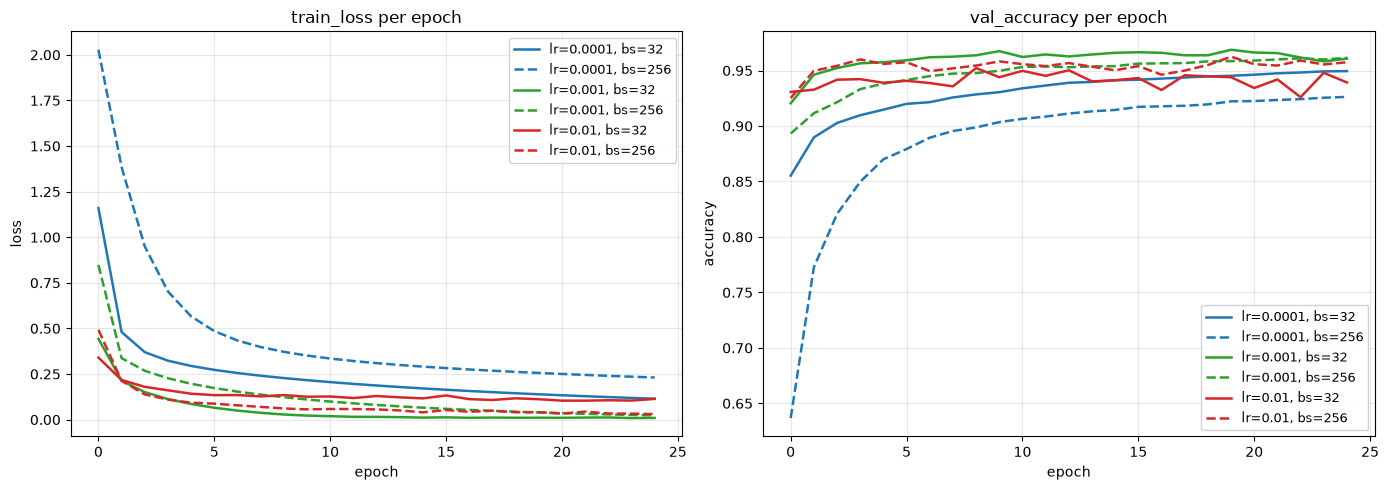

In [21]:
# =====================================================================
# Curves — six lines, readable legend
#
# Colour encodes learning rate, line style encodes batch size, so runs
# are distinguishable without squinting at eighteen legend entries.
# Plotted in a fixed (lr, batch_size) order rather than accuracy order,
# so the legend reads logically.
# =====================================================================
import matplotlib.pyplot as plt

client = mlflow.tracking.MlflowClient()

plot_order = table.sort_values(["lr", "batch_size"]).reset_index(drop=True)

LR_COLOURS = {0.0001: "#1f77b4", 0.001: "#2ca02c", 0.01: "#d62728"}
BS_STYLES = {32: "-", 256: "--"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for _, row in plot_order.iterrows():
    colour = LR_COLOURS.get(row["lr"], "#7f7f7f")
    style = BS_STYLES.get(row["batch_size"], ":")
    label = f"lr={row['lr']:g}, bs={row['batch_size']}"

    train_hist = client.get_metric_history(row["run_id"], "train_loss")
    val_hist = client.get_metric_history(row["run_id"], "val_accuracy")

    ax1.plot([m.step for m in train_hist], [m.value for m in train_hist],
             color=colour, linestyle=style, linewidth=1.8, label=label)
    ax2.plot([m.step for m in val_hist], [m.value for m in val_hist],
             color=colour, linestyle=style, linewidth=1.8, label=label)

ax1.set_title("train_loss per epoch")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.grid(alpha=0.3)
ax1.legend(fontsize=9, framealpha=0.9)

ax2.set_title("val_accuracy per epoch")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.grid(alpha=0.3)
ax2.legend(fontsize=9, loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.savefig("curves.png", dpi=150)
plt.show()

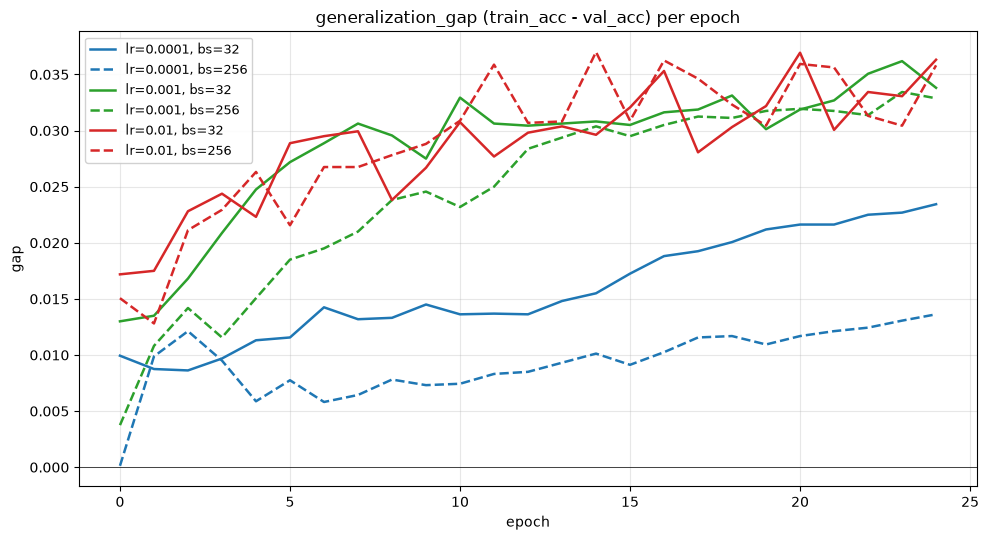

Gap widening per run :

lr=0.0001   bs=32   start=+0.0099  end=+0.0234  change=+0.0135
lr=0.0001   bs=256  start=+0.0001  end=+0.0136  change=+0.0135
lr=0.001    bs=32   start=+0.0130  end=+0.0338  change=+0.0208
lr=0.001    bs=256  start=+0.0038  end=+0.0329  change=+0.0291
lr=0.01     bs=32   start=+0.0172  end=+0.0363  change=+0.0191
lr=0.01     bs=256  start=+0.0151  end=+0.0358  change=+0.0208


In [22]:
plt.figure(figsize=(10, 5.5))

for _, row in plot_order.iterrows():
    colour = LR_COLOURS.get(row["lr"], "#7f7f7f")
    style = BS_STYLES.get(row["batch_size"], ":")
    label = f"lr={row['lr']:g}, bs={row['batch_size']}"
    hist = client.get_metric_history(row["run_id"], "generalization_gap")
    plt.plot([m.step for m in hist], [m.value for m in hist],
             color=colour, linestyle=style, linewidth=1.8, label=label)

plt.axhline(0, color="k", linewidth=0.5)
plt.title("generalization_gap (train_acc - val_acc) per epoch")
plt.xlabel("epoch"); plt.ylabel("gap"); plt.grid(alpha=0.3)
plt.legend(fontsize=9, loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.savefig("generalization_gap.png", dpi=150)
plt.show()

print("Gap widening per run :\n")
for _, row in plot_order.iterrows():
    vals = [m.value for m in client.get_metric_history(row["run_id"], "generalization_gap")]
    print(f"lr={row['lr']:<8g} bs={row['batch_size']:<4d} "
          f"start={vals[0]:+.4f}  end={vals[-1]:+.4f}  change={vals[-1] - vals[0]:+.4f}")

In [23]:

print(f"Best run          : {best_run['run_name']}")
print(f"  learning rate   = {best_run['lr']}")
print(f"  batch size      = {best_run['batch_size']}")
print(f"  best_val_acc    = {best_run['best_val_acc']:.4f} at epoch {int(best_run['best_epoch'])}")
print(f"  run_id          = {best_run['run_id']}")
print(f"Lowest train loss : {lowest_loss['run_name']} "
      f"(loss={lowest_loss['final_train_loss']:.4f}, val_acc={lowest_loss['best_val_acc']:.4f})")
print(f"LR spread         : {lr_spread:.4f}")
print(f"Batch size spread : {bs_spread:.4f}")
print(f"Larger effect     : {larger_effect}")
print(f"Subsample used    : {SUBSAMPLE}")
print(f"Epochs per run    : {EPOCHS}")
print("=" * 66)

Best run          : mlp-lr0.001-bs32
  learning rate   = 0.001
  batch size      = 32
  best_val_acc    = 0.9688 at epoch 19
  run_id          = 9f7a5a37776d493e8711b722854a3803
Lowest train loss : mlp-lr0.001-bs32 (loss=0.0095, val_acc=0.9688)
LR spread         : 0.0272
Batch size spread : 0.0068
Larger effect     : learning rate
Subsample used    : 20000
Epochs per run    : 25


In [24]:
# =====================================================================
# =====================================================================

for _, row in table.sort_values(["lr", "batch_size"]).iterrows():
    print(f"  {row['run_name']:24s}  {row['run_id']}")
print(f"\nTotal: {len(table)} runs")

  mlp-lr0.0001-bs32         533eb09c51274c9cbe612514ed300ac1
  mlp-lr0.0001-bs256        acf7007041834b21a01295ab43d5fac1
  mlp-lr0.001-bs32          9f7a5a37776d493e8711b722854a3803
  mlp-lr0.001-bs256         ec6ddab6e4814928bb507adc51b7d280
  mlp-lr0.01-bs32           ed856779134541018d86899d734d9a29
  mlp-lr0.01-bs256          ca2550fb23fb47e29459c8be70aa4b75

Total: 6 runs
